In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)

iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, iedb_II_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_II.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

iedb_II = iedb_II.with_columns(pl.Series(name="p_dgeom", values=iedb_II_p_dgeom))

/tmp/ipykernel_1795941/941664387.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(cats))


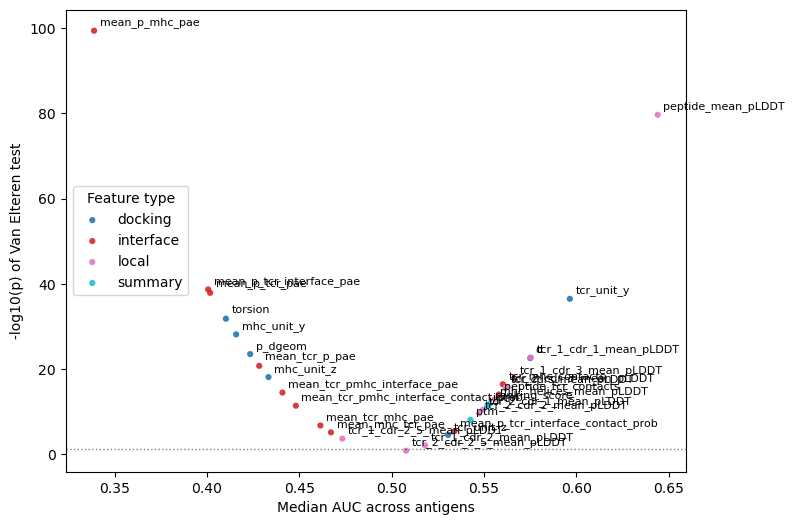

In [ ]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc
import sklearn.metrics as metrics
from scipy.stats import mannwhitneyu, norm, false_discovery_control
import numpy as np
import matplotlib.pyplot as plt


def plot_volcano(df, featnames, feat_type, grouping_cols=FORMAT_ANTIGEN_COLS):

    antigens = df.select(grouping_cols).unique()

    pvals = []
    aucs = []

    cog_arr = df.select("cognate").to_series().to_numpy()

    for feat in featnames:
        feat_arr = df.select(feat).to_series().to_numpy()
        auc = metrics.roc_auc_score(cog_arr, feat_arr)

        aucs.append(auc)

        stat, pval = mannwhitneyu(
            feat_arr[cog_arr],
            feat_arr[~cog_arr],
            alternative="greater" if auc > 0.5 else "less",
        )

        pvals.append(pval)

    neglog10p = -np.log10(np.array(pvals))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axhline(-np.log10(0.05), linestyle=":", linewidth=1, color="k", alpha=0.5)
    ax.set_xlabel("Median AUC across antigens")
    ax.set_ylabel("-log10(p) of Van Elteren test")

    cats = list(dict.fromkeys(feat_type))
    cmap = plt.cm.get_cmap("tab10", len(cats))
    color_for = {c: cmap(i) for i, c in enumerate(cats)}
    for c in cats:
        m = np.array(feat_type) == c
        ax.scatter(
            np.array(aucs)[m],
            np.array(neglog10p)[m],
            s=20,
            color=color_for[c],
            edgecolors="none",
            alpha=0.9,
            label=c,
        )

    ax.legend(title="Feature type")

    for i in range(len(featnames)):
        plt.annotate(
            str(featnames[i]),
            (aucs[i], neglog10p[i]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )


docking_feats = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "p_dgeom",
]

interface_feats = [
    "mean_p_tcr_interface_pae",
    "mean_tcr_pmhc_interface_pae",
    "mean_p_tcr_interface_contact_prob",
    "mean_tcr_pmhc_interface_contact_prob",
    "mean_p_tcr_pae",
    "mean_tcr_p_pae",
    "mean_mhc_tcr_pae",
    "mean_tcr_mhc_pae",
    "mean_p_mhc_pae",
    "tcr_mhc_contacts",
    "peptide_tcr_contacts",
]


local_feats = [
    "peptide_mean_pLDDT",
    "tcr_1_cdr_1_mean_pLDDT",
    "tcr_1_cdr_2_mean_pLDDT",
    "tcr_1_cdr_2_5_mean_pLDDT",
    "tcr_1_cdr_3_mean_pLDDT",
    "tcr_2_cdr_1_mean_pLDDT",
    "tcr_2_cdr_2_mean_pLDDT",
    "tcr_2_cdr_2_5_mean_pLDDT",
    "tcr_2_cdr_3_mean_pLDDT",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
]

summary_feats = [
    "iptm",
    "ptm",
    "ranking_score",
]

featnames = docking_feats + interface_feats + local_feats + summary_feats
feat_type = (
    ["docking"] * len(docking_feats)
    + ["interface"] * len(interface_feats)
    + ["local"] * len(local_feats)
    + ["summary"] * len(summary_feats)
)


plot_volcano(iedb_II, featnames, feat_type)